Task - implementing the DBSCAN clustering method

In [1]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [2]:
# loading the dataset
df=pd.read_csv('../data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Selecting features and scaling them
X=df.iloc[:,[3,4]].values

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
# print(X_scaled)

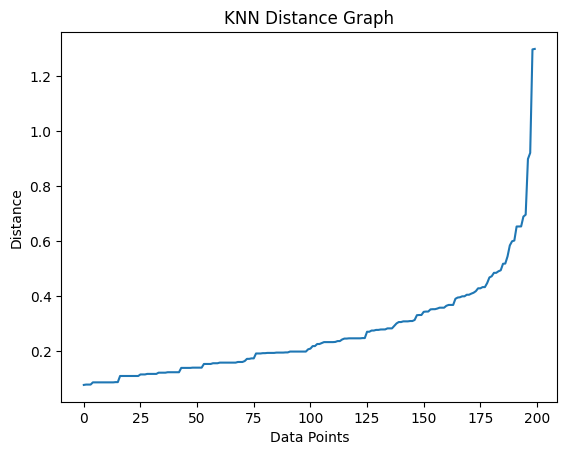

In [4]:
# Step 4: Find Best eps using KNN Distance Plot
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# sort distances
distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("KNN Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

The elbow point is at 0.5 so eps=0.5

In [5]:
# Step 5: Apply DBSCAN
dbscan= DBSCAN(eps=0.5, min_samples=5)

clusters = dbscan.fit_predict(X_scaled)

# add to dataframe
df['DBSCAN_Cluster'] = clusters

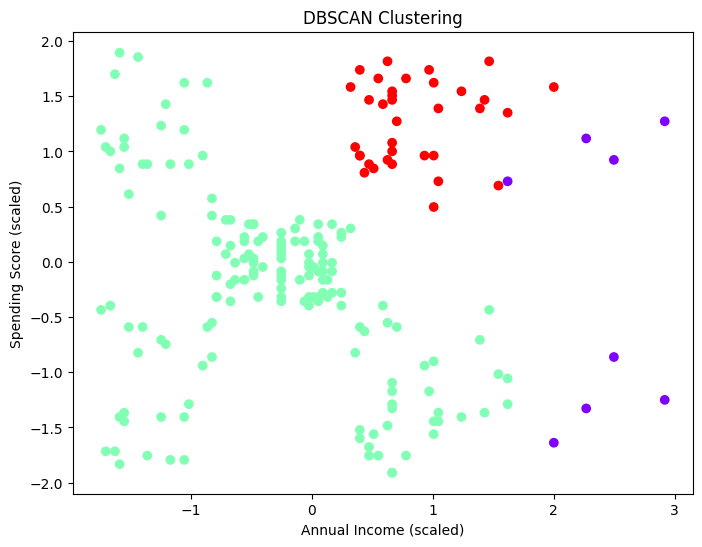

In [6]:
# Step 6: Visualizing the clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='rainbow'
)

plt.title("DBSCAN Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

In [7]:
# Step 8: check results
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64

There are 8 outliers present in the dataset
cluster 0 has 157 datapoints
cluster 1 has 35 datapoints

Saving the model

In [8]:
import joblib

joblib.dump(dbscan, "../models/dbscan_model.pkl")

['../models/dbscan_model.pkl']